# 1. 图像的格式与读写

In [ ]:
- 像素：
    -3~4字节构成：
        -3字节：R,G,B BGR(YUV): jpg,bmp,tiff,webp
        -4字节：RRBA()
        -
        -在python:
                - 元组tuple:(255,255,255,255): 透明度是通过运算体现。
                - 小数（0.5，0.3，0.8，1.0）：只能是0-1之间的小数 （matplotlib支持0-1小数）
                


In [ ]:
- opencv,torch图像格式：
    -numpy.ndarry
        -(H,W,C):
    -torch.Tensor:
        -(H,W,C)
- 3字节图像表示像素格式（伪彩色）
- 4字节（真彩色）

In [2]:
import numpy
# 生成表达式构造图像
# 数据（python：生成表达式）
data=[[[255,0,0] for _ in range(500)] 
for _ in range(400)]

#转化为numpy
img = numpy.array(data,dtype=numpy.uint8)                       #数组即使图像
img.shape

(400, 500, 3)

array([[[255,   0,   0],
        [255,   0,   0],
        [255,   0,   0],
        ...,
        [255,   0,   0],
        [255,   0,   0],
        [255,   0,   0]],

       [[255,   0,   0],
        [255,   0,   0],
        [255,   0,   0],
        ...,
        [255,   0,   0],
        [255,   0,   0],
        [255,   0,   0]],

       [[255,   0,   0],
        [255,   0,   0],
        [255,   0,   0],
        ...,
        [255,   0,   0],
        [255,   0,   0],
        [255,   0,   0]],

       ...,

       [[255,   0,   0],
        [255,   0,   0],
        [255,   0,   0],
        ...,
        [255,   0,   0],
        [255,   0,   0],
        [255,   0,   0]],

       [[255,   0,   0],
        [255,   0,   0],
        [255,   0,   0],
        ...,
        [255,   0,   0],
        [255,   0,   0],
        [255,   0,   0]],

       [[255,   0,   0],
        [255,   0,   0],
        [255,   0,   0],
        ...,
        [255,   0,   0],
        [255,   0,   0],
        [255,   0,   0]]

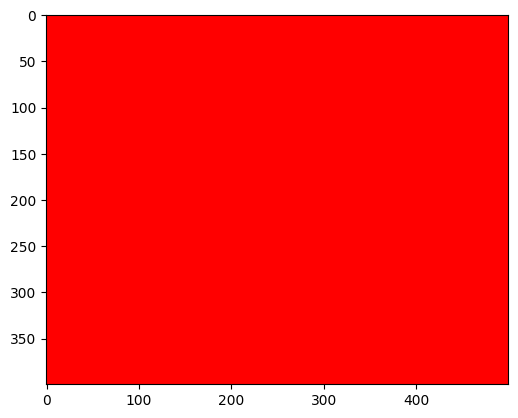

In [5]:
# 图像中3种显示
# 1. matplotlib
import matplotlib.pyplot as plt
plt.imshow(img)

#2. openCV                           #基本上不使用
import cv2 
cv2.imshow("window",img)
cv2.waitKey(3000)
cv2.destroyAllWindows()

#3. PIL
import PIL
image = PIL.Image.fromarray(img)
img

# 2. 图像的特征

- 什么是特征：
    - 像素变化就是特征：
        - 像素变化的数学模型：一阶导数/一阶差分
        - $f'(x) = \dfrac{f(x+\epsilon ) - f(x - \epsilon )}{2\epsilon}$
        - $f'(x) = \dfrac{f(x+1 ) - f(x - 1 )}{2}$ ,假设$\epsilon$=1

- 把导数变成代数表达式：
    $f'(x)=\begin{bmatrix}  {1}&{-1} \end{bmatrix}$   $\begin{bmatrix}  {f(x+1)}&\\ {f(x)} \end{bmatrix}$


In [ ]:
- 

(np.float64(-0.5), np.float64(1199.5), np.float64(812.5), np.float64(-0.5))

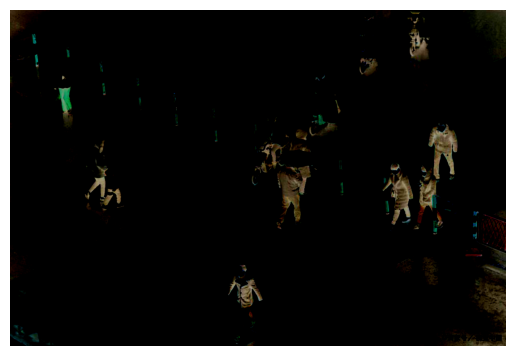

In [19]:
import cv2 
import matplotlib.pyplot as plt
import numpy as np
# 打开图像
img = cv2.imread("../../assets/images/04_traffic.jpg", cv2.IMREAD_COLOR_RGB)
# 准备核
kernel = np.array(
    [
        [0, -1, 0],
        [-1, 0, -1],
        [0, -1, 0]
    ]
)

# 使用filter2D做卷积运算
feature_map = cv2.filter2D(img, -1, kernel=kernel, delta=160)

# 可视化
# plt. figure(figsize=(4.8, 2 * 3.2))

# plt.subplot(121)
# plt.imshow(img)


# plt.subplot(122)
plt.imshow(feature_map)
plt.axis("off")